In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataset/merged_crop_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (179726, 10)


,State_Name,District_Name,Year,Season,Crop,Area,Production,Yield,Annual_Rainfall,Avg_Price
0,Andhra Pradesh,Anantapur,1997,Kharif,Arhar (Tur/Red Gram)(Whole),21400.0,2600.0,0.121495,972.1,8600.000
1,Andhra Pradesh,Anantapur,1997,Kharif,Castor Seed,1000.0,100.0,0.100000,972.1,6126.500
2,Andhra Pradesh,Anantapur,1997,Kharif,Cotton,7300.0,9400.0,1.287671,972.1,7050.000
3,Andhra Pradesh,Anantapur,1997,Kharif,Dry Chillies,3700.0,7100.0,1.918919,972.1,18712.625
4,Andhra Pradesh,Anantapur,1997,Kharif,Groundnut,650800.0,228400.0,0.350953,972.1,6964.600


In [2]:
df['Annual_Rainfall'] = df.groupby('State_Name')['Annual_Rainfall']\
                          .transform(lambda x: x.fillna(x.median()))
df['Annual_Rainfall'].fillna(df['Annual_Rainfall'].median(), inplace=True)

q99 = df['Yield'].quantile(0.99)
df = df[df['Yield'] <= q99]

print("After cleaning:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

After cleaning: (177928, 10)
Remaining nulls: 0


In [3]:
le_state   = LabelEncoder()
le_district = LabelEncoder()
le_season  = LabelEncoder()
le_crop    = LabelEncoder()

df['State_Enc']    = le_state.fit_transform(df['State_Name'])
df['District_Enc'] = le_district.fit_transform(df['District_Name'])
df['Season_Enc']   = le_season.fit_transform(df['Season'])
df['Crop_Enc']     = le_crop.fit_transform(df['Crop'])

import os
os.makedirs('models', exist_ok=True)
joblib.dump(le_state,    'models/le_state.pkl')
joblib.dump(le_district, 'models/le_district.pkl')
joblib.dump(le_season,   'models/le_season.pkl')
joblib.dump(le_crop,     'models/le_crop.pkl')

print("Encoding done.")
print("Seasons:", list(le_season.classes_))
print("Sample crops:", list(le_crop.classes_)[:10])

Encoding done.
Seasons: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']
Sample crops: ['Arecanut(Betelnut/Supari)', 'Arhar (Tur/Red Gram)(Whole)', 'Bajra(Pearl Millet/Cumbu)', 'Banana', 'Barley (Jau)', 'Beans', 'Bhindi(Ladies Finger)', 'Black Pepper', 'Brinjal', 'Cardamoms']


In [4]:
FEATURES = ['State_Enc', 'District_Enc', 'Season_Enc', 
            'Crop_Enc', 'Annual_Rainfall', 'Year']

TARGET = 'Yield'

X = df[FEATURES]
y = df[TARGET]

train_df = df[df['Year'] <= 2008]
test_df  = df[df['Year'] >  2008]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (119330, 6)
Test size:  (58598, 6)


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mae  = mean_absolute_error(y_test, rf_preds)
r2   = r2_score(y_test, rf_preds)

print("=== Random Forest ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

=== Random Forest ===
RMSE : 2.3489
MAE  : 1.0333
R²   : 0.8203


In [6]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=50)

xgb_preds = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae  = mean_absolute_error(y_test, xgb_preds)
r2   = r2_score(y_test, xgb_preds)

print("\n=== XGBoost ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

[0]	validation_0-rmse:5.39187
[50]	validation_0-rmse:2.63608
[100]	validation_0-rmse:2.39128
[150]	validation_0-rmse:2.32712
[200]	validation_0-rmse:2.30639
[250]	validation_0-rmse:2.29794
[299]	validation_0-rmse:2.28791

=== XGBoost ===
RMSE : 2.2879
MAE  : 1.0569
R²   : 0.8296


In [7]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gbr_model.fit(X_train, y_train)
gbr_preds = gbr_model.predict(X_test)

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

models_results = {
    'Random Forest'       : rf_preds,
    'XGBoost'             : xgb_preds,
    'Gradient Boosting'   : gbr_preds,
    'Ridge Regression'    : ridge_preds,
}

print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 55)
for name, preds in models_results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    print(f"{name:<25} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

Model                         RMSE      MAE       R²
-------------------------------------------------------
Random Forest               2.3489   1.0333   0.8203
XGBoost                     2.2879   1.0569   0.8296
Gradient Boosting           2.2981   1.1437   0.8280
Ridge Regression            5.3529   3.1671   0.0670


In [ ]:
from sklearn.ensemble import StackingRegressor

# Base learners
estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, max_depth=15, 
                                   n_jobs=-1, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, max_depth=8,
                               learning_rate=0.05, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, max_depth=6,
                                       random_state=42))
]

# Meta-learner
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

print("Training Stacking model")
stacking_model.fit(X_train, y_train)
stack_preds = stacking_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, stack_preds))
mae  = mean_absolute_error(y_test, stack_preds)
r2   = r2_score(y_test, stack_preds)

print(f"\n=== Stacking Regressor ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Training Stacking model


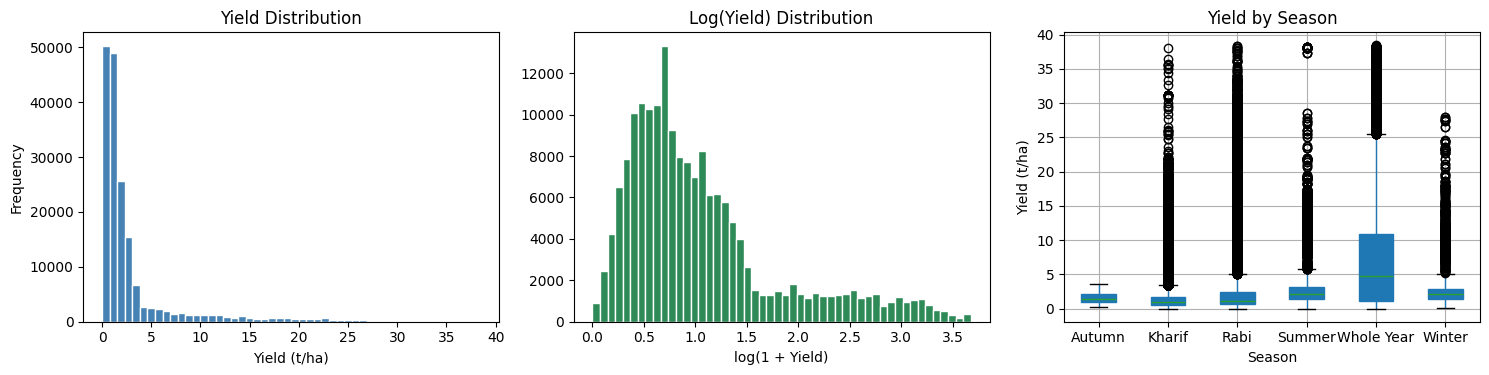


Yield stats:
count    177928.000000
mean          3.225897
std           5.345431
min           0.000340
25%           0.699805
50%           1.310345
75%           2.685274
max          38.434940
Name: Yield, dtype: float64

Skewness: 3.224
(Values > 1 indicate right skew — common in agricultural data)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Yield distribution
axes[0].hist(df['Yield'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Yield Distribution')
axes[0].set_xlabel('Yield (t/ha)')
axes[0].set_ylabel('Frequency')

# Plot 2: Log-transformed yield
axes[1].hist(np.log1p(df['Yield']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Log(Yield) Distribution')
axes[1].set_xlabel('log(1 + Yield)')

# Plot 3: Yield by season
df.boxplot(column='Yield', by='Season', ax=axes[2], 
           patch_artist=True)
axes[2].set_title('Yield by Season')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Yield (t/ha)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('models/yield_distribution.png')
plt.show()

print(f"\nYield stats:")
print(df['Yield'].describe())
print(f"\nSkewness: {df['Yield'].skew():.3f}")

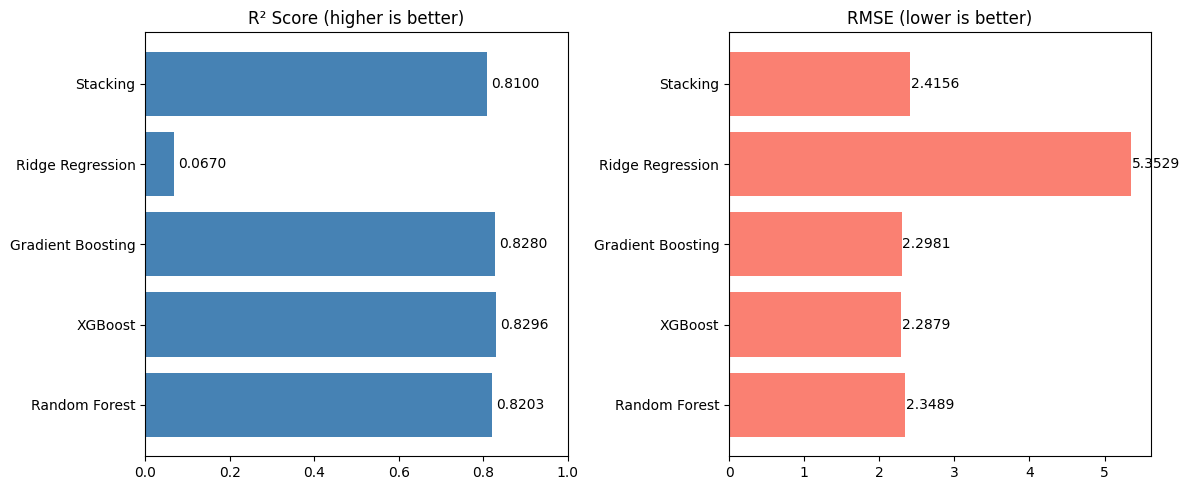

In [ ]:
all_results = {
    'Random Forest'     : rf_preds,
    'XGBoost'           : xgb_preds,
    'Gradient Boosting' : gbr_preds,
    'Ridge Regression'  : ridge_preds,
    'Stacking'          : stack_preds,
}

names, r2_scores, rmse_scores = [], [], []
for name, preds in all_results.items():
    names.append(name)
    r2_scores.append(r2_score(y_test, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, preds)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(names, r2_scores, color='steelblue')
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

axes[1].barh(names, rmse_scores, color='salmon')
axes[1].set_title('RMSE (lower is better)')
for i, v in enumerate(rmse_scores):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('models/model_comparison.png')
plt.show()

In [ ]:
best_name  = names[np.argmax(r2_scores)]
best_preds = list(all_results.values())[np.argmax(r2_scores)]

model_objects = {
    'Random Forest'     : rf_model,
    'XGBoost'           : xgb_model,
    'Gradient Boosting' : gbr_model,
    'Ridge Regression'  : ridge_model,
    'Stacking'          : stacking_model,
}

best_model = model_objects[best_name]
joblib.dump(best_model, 'models/yield_model.pkl')
print(f"✅ Best model: {best_name} (R² = {max(r2_scores):.4f})")
print("✅ Saved to models/yield_model.pkl")

✅ Best model: XGBoost (R² = 0.8296)
✅ Saved to models/yield_model.pkl


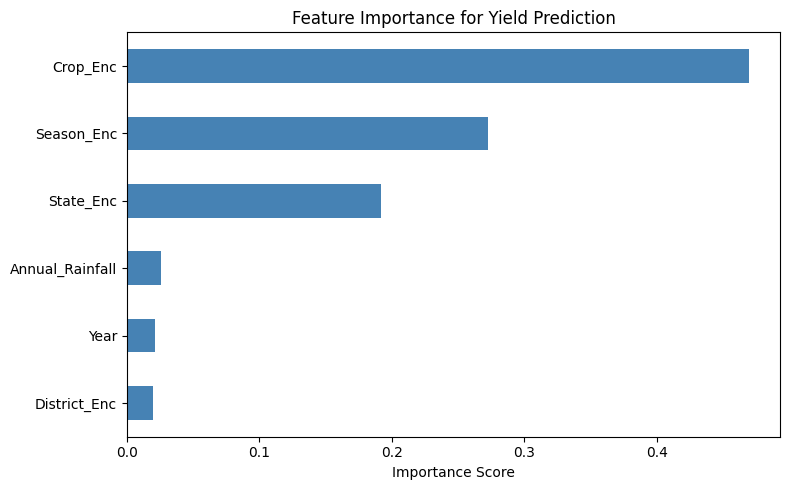

In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Feature Importance for Yield Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('models/feature_importance.png')
plt.show()